# BDL-HW 1

## Classic_method

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# Load Data
df_train = pd.read_csv('train_data.csv').fillna('')
df_test = pd.read_csv('test_data.csv').fillna('')

X_train = df_train['text']
y_train = df_train['is_ai']
X_test = df_test['text']
y_test = df_test['is_ai']

In [3]:
# Represent documents by tf-idf
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train).toarray()

# Apply PCA to reduce dimensions and obtain dense vectors
pca = PCA(n_components=200, random_state=42)
X_train_pca = pca.fit_transform(X_train_tfidf)

X_test_tfidf = tfidf.transform(X_test).toarray()
X_test_pca = pca.transform(X_test_tfidf)

# Create the prediction model
clf = LogisticRegression(random_state=42)

# Model training
clf.fit(X_train_pca, y_train)

LogisticRegression(random_state=42)

In [4]:
# Prediction on test data
y_pred = clf.predict(X_test_pca)

# Assess the prediction performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.57


## Deep_method

In [5]:
import copy
import torch
import itertools
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

In [7]:
# 載入 BGE-M3 模型並設定最大長度
#device = "cuda" if torch.cuda.is_available() else "cpu"
#print(f"目前使用的運算裝置: {device}")
#model = SentenceTransformer('BAAI/bge-m3', device=device)
#model.max_seq_length = 8192
#device = "cuda" if torch.cuda.is_available() else "cpu"
#model = SentenceTransformer('BAAI/bge-m3', device=device)

# 轉換 Embeddings (設定 normalize_embeddings=True 提升特徵品質)
#X_train_embeddings = model.encode(X_train, show_progress_bar=True)
#X_test_embeddings = model.encode(X_test, show_progress_bar=True)

# 切分訓練集與驗證集 (Train/Val Split, 80/20)
#X_train, X_val, y_train, y_val = train_test_split(
#    X_train_embeddings, y_train_raw, test_size=0.2, random_state=42
#)

# 把data存起來之後就不用跑這段
#np.save('X_train.npy', X_train)
#np.save('X_val.npy', X_val)
#np.save('X_test.npy', X_test_embeddings)

#np.save('y_train.npy', y_train)
#np.save('y_val.npy', y_val)
#np.save('y_test.npy', y_test_labels)

#print("所有特徵與標籤已成功儲存為 .npy 檔案。")

In [8]:
class TextDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]

class MLP(nn.Module):
    def __init__(self, input_dim, num_layers, hidden_dim, activation_name, dropout_rate):
        super(MLP, self).__init__()
        layers = []

        # 選擇 Activation Function
        act_dict = {
            'ReLU': nn.ReLU(),
            'Sigmoid': nn.Sigmoid(),
            'GELU': nn.GELU(),
            'SiLU': nn.SiLU()
        }
        act_fn = act_dict.get(activation_name, nn.ReLU())

        current_dim = input_dim
        # 動態建立隱藏層 (根據 num_layers)
        for _ in range(num_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(act_fn)
            layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        # 輸出層 (二分類使用 Sigmoid)
        layers.append(nn.Linear(current_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [9]:
def train_model(config, patience=10):
    train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(TextDataset(X_val, y_val), batch_size=32)

    model = MLP(
        input_dim=1024,
        num_layers=config['num_layers'],
        hidden_dim=config['hidden_dim'],
        activation_name=config['activation'],
        dropout_rate=config['dropout']
    ).to(device)
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-3)

    criterion = nn.BCELoss()

    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # 4. 訓練輪數 (根據 config['epochs'])
    for epoch in range(config['epochs']):
        model.train()
        t_loss, correct_train, total_train = 0, 0, 0

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            t_loss += loss.item()
            preds = (outputs >= 0.5).float()
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        t_loss /= len(train_loader)
        t_acc = correct_train / total_train

        model.eval()
        v_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                v_loss += criterion(outputs, labels).item()
                preds = (outputs >= 0.5).float()
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        v_loss /= len(val_loader)
        v_acc = correct_val / total_val

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_weights)
    return model, train_losses, val_losses, train_accs, val_accs

Early stopping at epoch 33


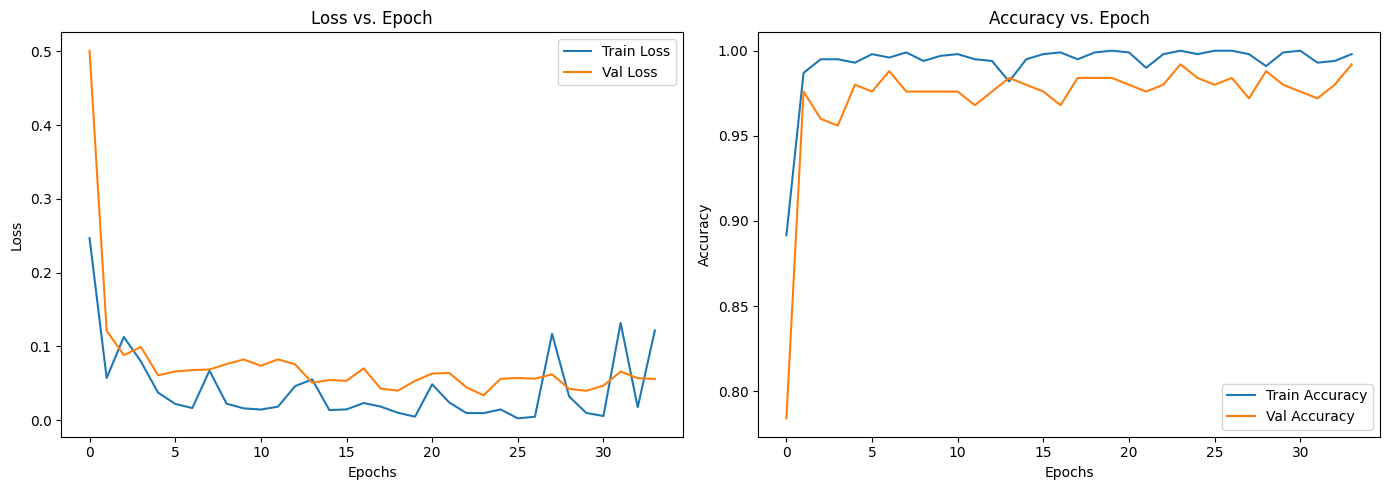

In [10]:
# 做一次
test_config = {
    'num_layers': 2,           # 1. Hidden layers
    'hidden_dim': 256,         # 2. Neurons per layer
    'lr': 0.001,               # 3. Learning rate
    'epochs': 50,             # 4. Epochs
    'activation': 'ReLU',      # 5. Activation
    'optimizer': 'AdamW',      # 6. Optimizer
    'dropout': 0.2             # 7. Dropout rate
}
trained_model, t_losses, v_losses, t_accs, v_accs = train_model(test_config)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# 畫出 Loss 曲線
ax1.plot(t_losses, label='Train Loss')
ax1.plot(v_losses, label='Val Loss')
ax1.set_title("Loss vs. Epoch")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()
# 劃出 Accuracy
ax2.plot(t_accs, label='Train Accuracy')
ax2.plot(v_accs, label='Val Accuracy')
ax2.set_title("Accuracy vs. Epoch")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
trained_model.eval()

# 將測試集轉為 Tensor 並放到運算裝置上
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# 關閉梯度計算進行預測
with torch.no_grad():
    outputs = trained_model(X_test_tensor)
    # 將輸出機率轉為 0 或 1 的標籤 (閾值 0.5)
    predictions = (outputs >= 0.5).squeeze().float()

# 計算並輸出準確率
accuracy = accuracy_score(y_test, predictions.cpu().numpy())
print(f"目前配置的測試集準確率: {accuracy:.4f}")

目前配置的測試集準確率: 0.7547


In [12]:
test_loader = DataLoader(TextDataset(X_test, y_test), batch_size=32, shuffle=False)

# 定義搜尋網格
param_grid = {
    'activation': ['ReLU', 'SiLU'],
    'num_layers': [1, 2],
    'optimizer': ['Adam', 'AdamW'],
    'hidden_dim': [64, 128, 256],
    'lr': [0.01, 0.001],
    'dropout': [0.2, 0.35, 0.5],
    'epochs': [10, 50]
}

keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []
best_val_acc_so_far = -1
best_model_info = None  # 用來存儲畫圖所需的數據

print(f"開始系統性研究，預計執行總實驗數: {len(experiments)} [cite: 48]")

for i, config in enumerate(experiments):
    # 執行訓練
    trained_model, t_losses, v_losses, t_accs, v_accs = train_model(config, patience=10)

    # 取出該次實驗中「最好的驗證準確率」 (用於 Model Selection)
    current_best_v_acc = max(v_accs)

    # 在測試集上評估 (用於最後 Test Accuracy 評分)
    trained_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = trained_model(features)
            preds = (outputs >= 0.5).float()
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)
    current_test_acc = correct_test / total_test

    # 紀錄結果至 List
    res_entry = config.copy()
    res_entry['best_val_acc'] = current_best_v_acc
    res_entry['test_acc'] = current_test_acc
    results.append(res_entry)

    # 2. 根據 Validation Accuracy 更新「最終模型資訊」
    if current_best_v_acc > best_val_acc_so_far:
        best_val_acc_so_far = current_best_v_acc
        # 儲存你指定的畫圖變數
        best_model_info = (config, t_losses, v_losses, t_accs, v_accs, current_test_acc)
        print(f"✨ 發現更好的驗證組合！Val Acc: {current_best_v_acc:.4f} | Test Acc: {current_test_acc:.4f}")

開始系統性研究，預計執行總實驗數: 288 [cite: 48]
✨ 發現更好的驗證組合！Val Acc: 0.9840 | Test Acc: 0.7413
Early stopping at epoch 34
✨ 發現更好的驗證組合！Val Acc: 0.9960 | Test Acc: 0.7300
Early stopping at epoch 24
Early stopping at epoch 32
Early stopping at epoch 19
Early stopping at epoch 21
Early stopping at epoch 22
Early stopping at epoch 20
Early stopping at epoch 11
Early stopping at epoch 19
Early stopping at epoch 23
Early stopping at epoch 20
Early stopping at epoch 15
Early stopping at epoch 14
Early stopping at epoch 16
Early stopping at epoch 18
Early stopping at epoch 20
Early stopping at epoch 25
Early stopping at epoch 25
Early stopping at epoch 18
Early stopping at epoch 12
Early stopping at epoch 26
Early stopping at epoch 18
Early stopping at epoch 23
Early stopping at epoch 21
Early stopping at epoch 11
Early stopping at epoch 15
Early stopping at epoch 23
Early stopping at epoch 23
Early stopping at epoch 28
Early stopping at epoch 28
Early stopping at epoch 16
Early stopping at epoch 18
Early sto

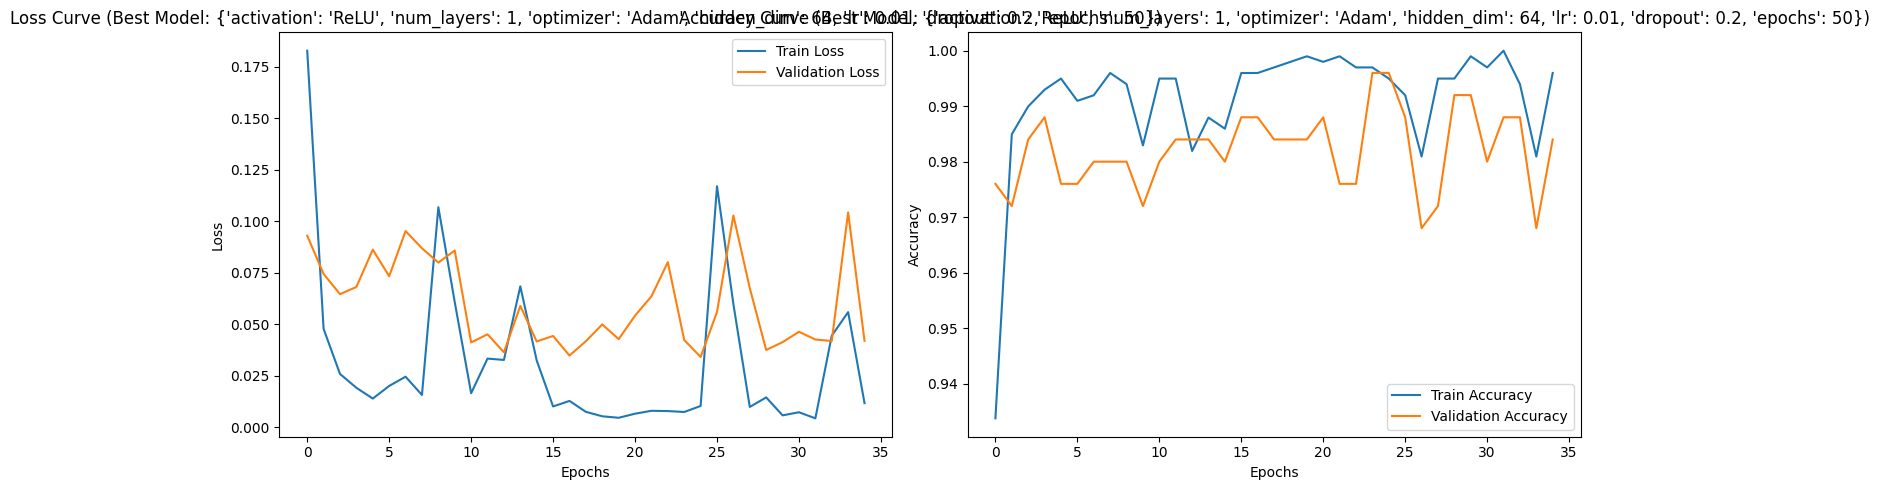

In [13]:
# 繪製最佳模型的 Loss 與 Accuracy 曲線
best_config, best_t_losses, best_v_losses, best_t_accs, best_v_accs, best_test = best_model_info

# 建立 1x2 的子圖表 (左邊畫 Loss，右邊畫 Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 繪製 Loss 曲線
ax1.plot(best_t_losses, label='Train Loss')
ax1.plot(best_v_losses, label='Validation Loss')
ax1.set_title(f"Loss Curve (Best Model: {best_config})")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()

# 繪製 Accuracy 曲線
ax2.plot(best_t_accs, label='Train Accuracy')
ax2.plot(best_v_accs, label='Validation Accuracy')
ax2.set_title(f"Accuracy Curve (Best Model: {best_config})")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
print('此次選出來的Testing Accuracy:',best_test)

此次選出來的Testing Accuracy: 0.73


In [15]:
print('此次選出來的:',best_config)

此次選出來的: {'activation': 'ReLU', 'num_layers': 1, 'optimizer': 'Adam', 'hidden_dim': 64, 'lr': 0.01, 'dropout': 0.2, 'epochs': 50}
